The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


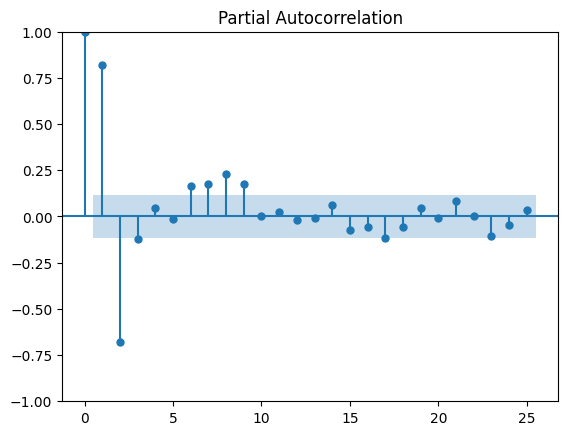

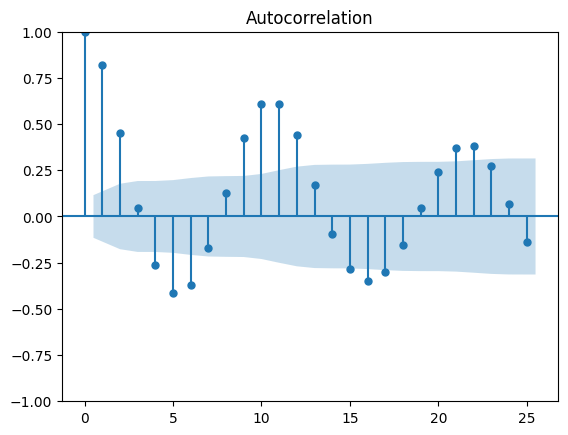

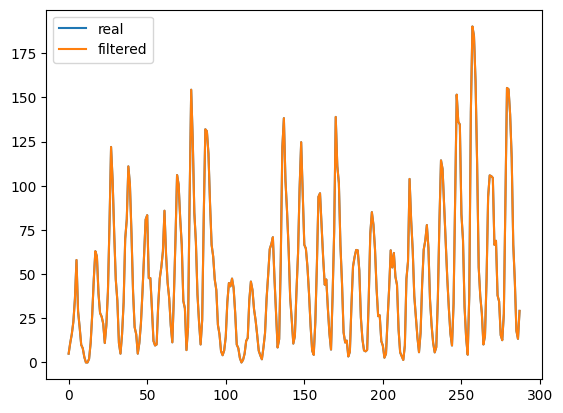

Serie: sunspot.txt is_stationary False lags: 9 linhas: 251


,count,mean,std,min,25%,50%,75%,max,train_size,test_size,val_size
0,288.0,48.434375,39.424986,0.0,15.575,39.0,68.3,190.2,260,0,28


****************************************************************************************************


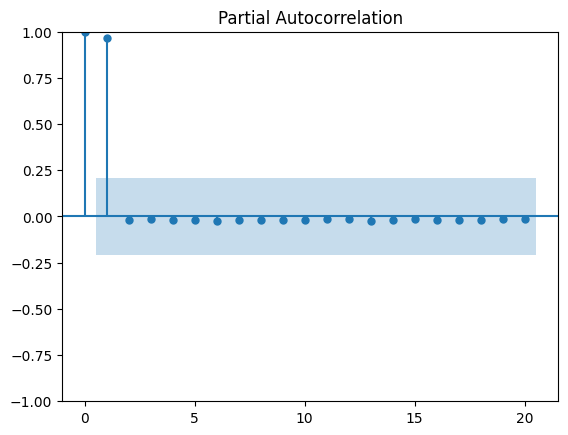

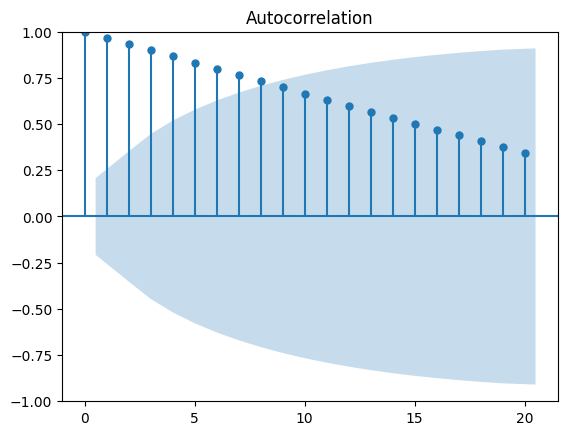

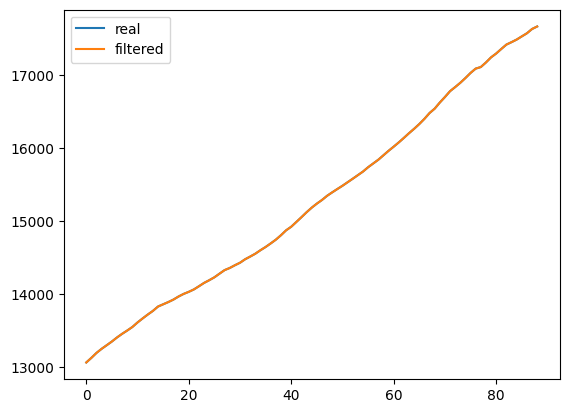

Serie: austres.txt is_stationary False lags: 1 linhas: 80


,count,mean,std,min,25%,50%,75%,max,train_size,test_size,val_size
0,89.0,15273.449438,1356.812524,13067.3,14110.1,15184.2,16398.9,17661.5,81,0,8


****************************************************************************************************


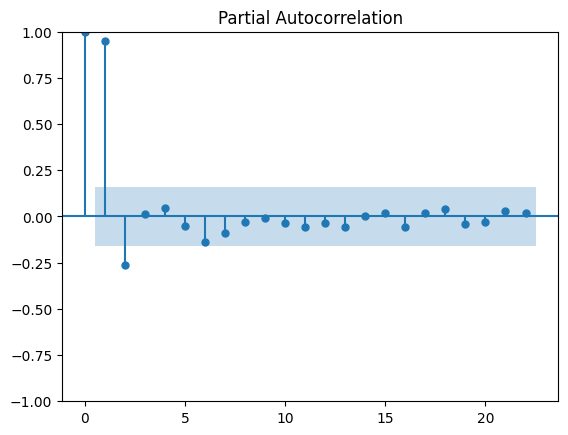

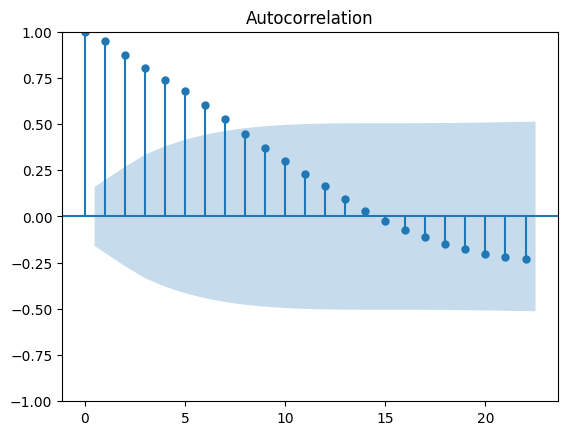

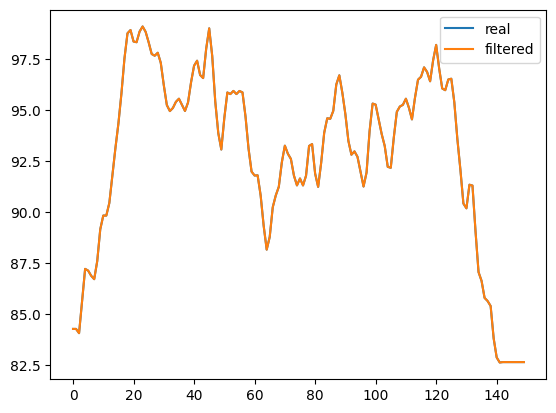

Serie: heartrate.txt is_stationary False lags: 2 linhas: 133


,count,mean,std,min,25%,50%,75%,max,train_size,test_size,val_size
0,150.0,92.743578,4.440091,82.6266,90.911225,93.72345,95.90335,99.0789,135,0,15


****************************************************************************************************


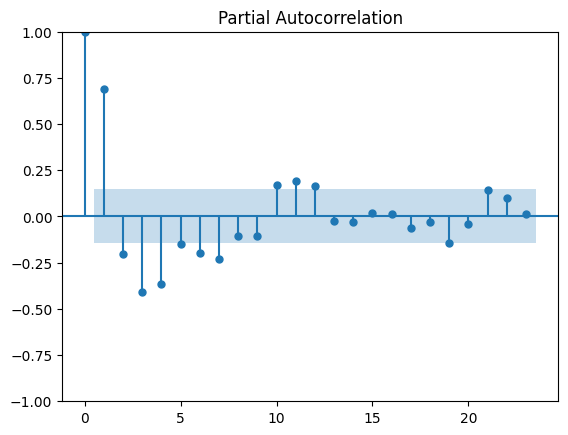

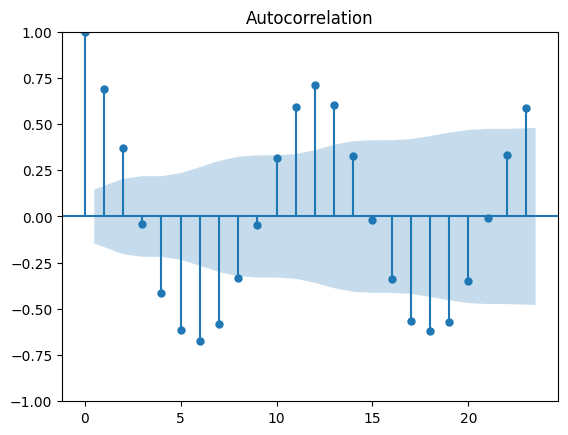

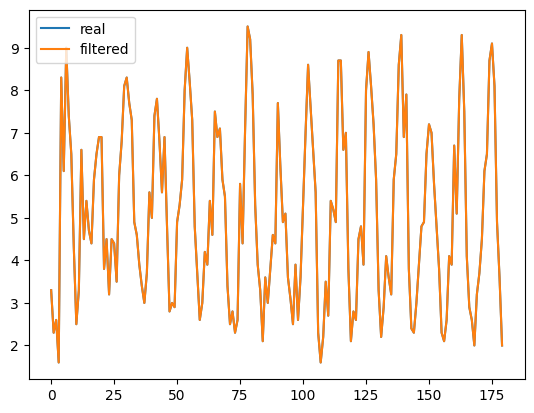

Serie: ozon.txt is_stationary False lags: 12 linhas: 150


,count,mean,std,min,25%,50%,75%,max,train_size,test_size,val_size
0,180.0,5.098333,2.074169,1.6,3.375,4.8,6.9,9.5,162,0,18


****************************************************************************************************


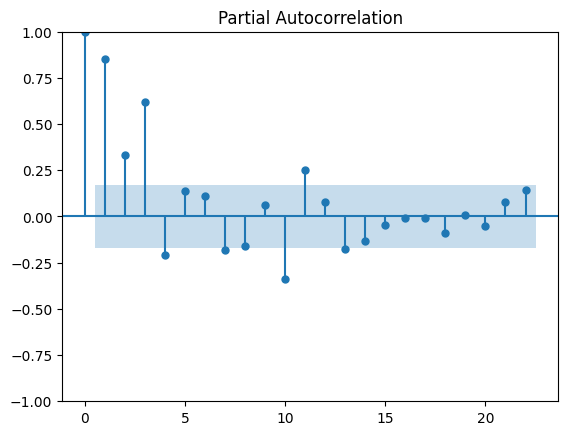

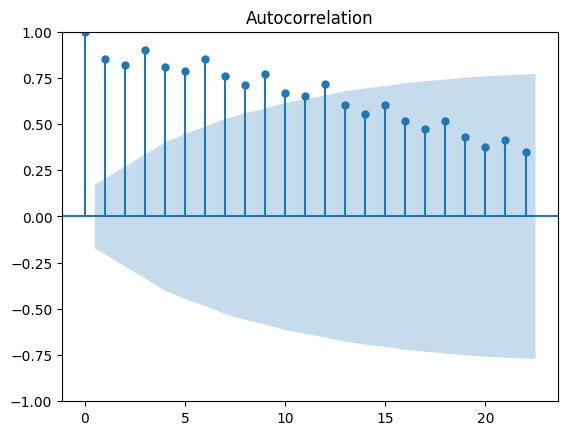

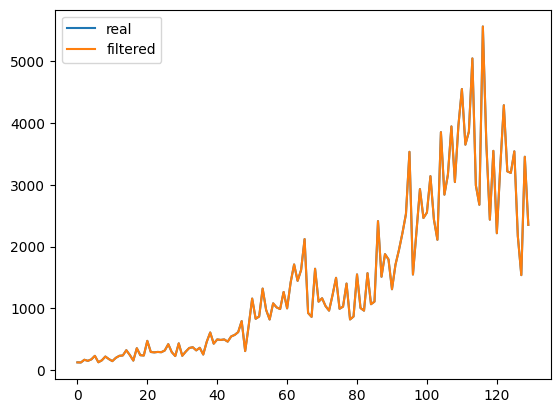

Serie: pollution.txt is_stationary False lags: 13 linhas: 104


,count,mean,std,min,25%,50%,75%,max,train_size,test_size,val_size
0,130.0,1439.261223,1261.231265,120.888,356.532,1019.664,2218.689,5566.103,117,0,13


****************************************************************************************************


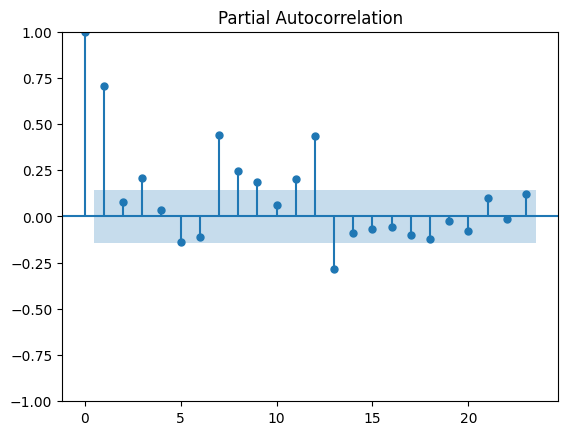

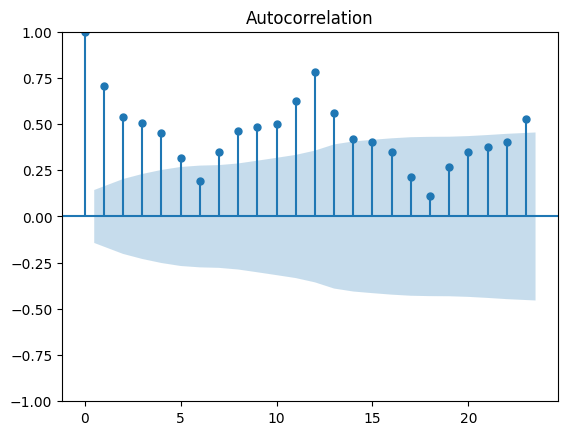

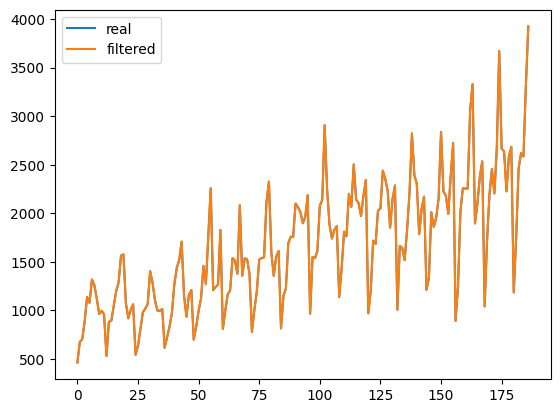

Serie: redwine.txt is_stationary False lags: 16 linhas: 153


,count,mean,std,min,25%,50%,75%,max,train_size,test_size,val_size
0,187.0,1664.064171,648.979626,464.0,1138.5,1596.0,2144.0,3923.0,169,0,18


****************************************************************************************************


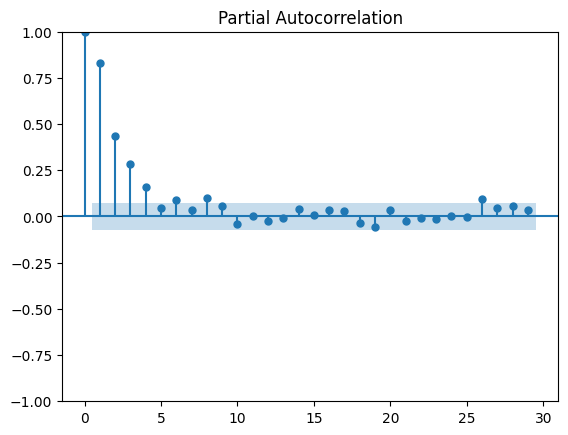

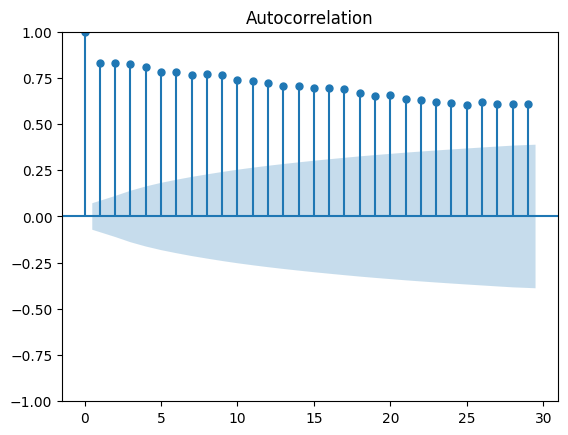

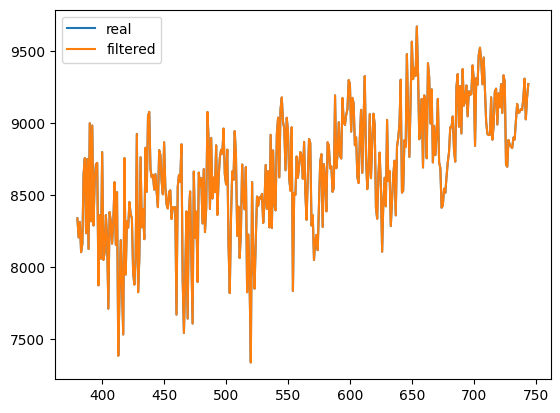

Serie: gasoline.txt is_stationary False lags: 8 linhas: 663


,count,mean,std,min,25%,50%,75%,max,train_size,test_size,val_size
0,745.0,8135.86346,689.152748,6321.0,7578.0,8162.0,8685.0,9668.0,671,0,74


****************************************************************************************************


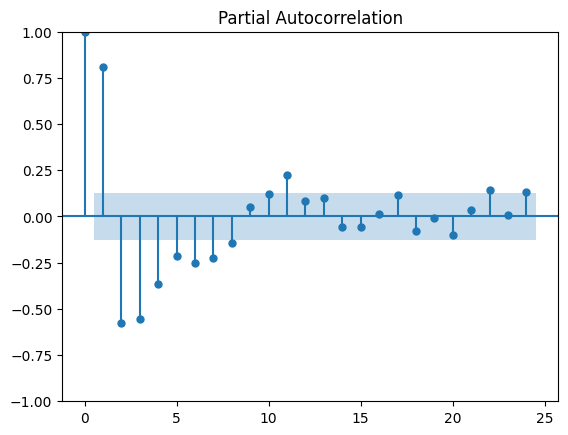

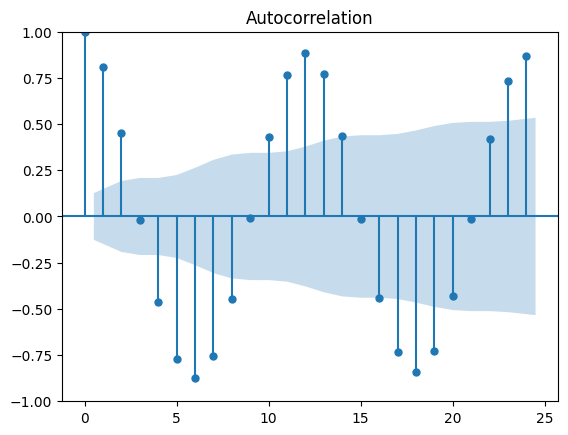

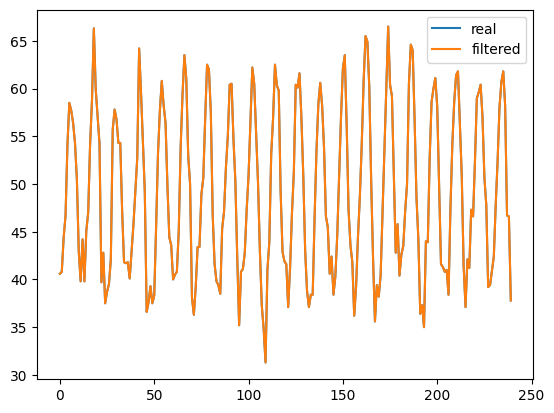

Serie: temperature.txt is_stationary False lags: 20 linhas: 196


,count,mean,std,min,25%,50%,75%,max,train_size,test_size,val_size
0,240.0,49.04125,8.569705,31.3,41.55,47.35,57.0,66.5,216,0,24


****************************************************************************************************


In [2]:
from input import input
import config
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

%load_ext autoreload
%autoreload 2
    
normalize = False
diff_kpss = False
lag_size = 7
exec_config = {
    "test_size": config.TEST_SIZE,
    "val_size": 0,
    'horizon': 1,
    'normalize': normalize,
    'diff_kpss': diff_kpss,
    'type_filter': None
}

for base_name in config.BASE_NAME_LIST:
    exec_config['lag_size'] = config.BASE_INFORMATION[base_name]['lag_size']
    (
        ts_univariate,
        df_train, 
        df_val,
        df_test, 
        min_max_scaler,
        test_size, 
        val_size,
        is_stationary, 
        original_ts,
        lag_size_formated
        
    ) = input.open_format_train_val_test(base_name, exec_config).sequential_return()
    
    plot_pacf(ts_univariate)
    #plt.savefig(f'{base_name}pacf.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    plot_acf(ts_univariate)
    #plt.savefig(f'{base_name}acf.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    pd.DataFrame(
        {'real': original_ts[-ts_univariate.shape[0]:],
        'filtered': ts_univariate}
    ).iloc[-365:].plot()
    plt.show()
    #result = seasonal_decompose(original_ts, model='additive', period=12)
    #fig = result.plot()
    #fig.set_size_inches(10, 8)
    #plt.tight_layout()
    #plt.show()
    print(f"Serie: {base_name} is_stationary {is_stationary} lags: {df_train.shape[1] -1} linhas: {df_train.shape[0]}")
    desc = pd.DataFrame(original_ts).describe().T
    desc['train_size'] = pd.DataFrame(original_ts).shape[0] - (test_size+val_size)
    desc['test_size'] = val_size
    desc['val_size'] = test_size
    display(desc)
    print('*' * 100)
